# Basic Propagation — First Optical Stack

This notebook is the **entry point for new users** in the example set. It builds a
minimal coherent optical system from a plane wave, a thin lens, and a planned
free-space propagator, then inspects the focal intensity and detector readout.

## Assumes you know

- what a wavelength and a sampled spatial grid represent,
- that optical intensity is the squared magnitude of a complex field, and
- the rough idea that a thin lens can focus a wavefront.

## New ideas in this notebook

- how `Grid`, `Spectrum`, and `Field` define a simulated optical state,
- how `OpticalModule` composes optical layers into a forward model,
- why `plan_propagation(...)` is the recommended entry point for propagation, and
- how a `Detector` turns a field into a scalar measurement over a region.

## Where to go next

- [`lens_optimization.ipynb`](lens_optimization.ipynb) for end-to-end phase optimization,
- [`4f_correlator.ipynb`](4f_correlator.ipynb) for a Fourier-optics system, or
- [`incoherent_camera.ipynb`](incoherent_camera.ipynb) for shift-invariant imaging.


## 0  Imports

We import the core `fouriax` objects together with NumPy and Matplotlib for a
small deterministic propagation experiment and a simple diagnostic plot.


In [1]:
from __future__ import annotations

import argparse
from pathlib import Path

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import fouriax as fx

import os
from pathlib import Path as _Path
%matplotlib inline

REPO_ROOT = fx.utils.find_repo_root(_Path.cwd())
if _Path.cwd() != REPO_ROOT:
    os.chdir(REPO_ROOT)


EXAMPLES_ROOT = Path(__file__).resolve().parents[1]
EXAMPLES_ARTIFACTS_DIR = EXAMPLES_ROOT / "artifacts"


## 1  Paths and Parameters

These parameters define the sampled optical problem: grid size and spacing,
wavelength, lens-to-sensor distance, and the aperture fraction cut into the lens.


In [2]:
ARTIFACTS_DIR = Path(str(EXAMPLES_ARTIFACTS_DIR))
PLOT_PATH = ARTIFACTS_DIR / "basic_propagation_overview.png"

GRID_N = 128
GRID_DX_UM = 0.5
WAVELENGTH_UM = 0.532
DISTANCE_UM = 50.0
APERTURE_FRACTION = 0.35
FOCUS_RADIUS_PX = 3.0
PLOT = True


## 2  Concept and Helper Functions

The helper below builds a circular spatial mask. We use it to define a compact
focus detector region around the center of the propagated intensity map.


In [3]:
def circular_region_mask(
    grid: fx.Grid,
    *,
    radius_um: float,
    center_xy: tuple[int, int] | None = None,
) -> jnp.ndarray:
    x_um, y_um = grid.spatial_grid()
    if center_xy is None:
        cx_um = 0.0
        cy_um = 0.0
    else:
        cx_px, cy_px = center_xy
        cx_um = (cx_px - (grid.nx - 1) / 2.0) * grid.dx_um
        cy_um = (cy_px - (grid.ny - 1) / 2.0) * grid.dy_um
    r2 = (x_um - cx_um) ** 2 + (y_um - cy_um) ** 2
    return (r2 <= radius_um * radius_um).astype(jnp.float32)


## 3  Setup

Here we build the main optics objects: a plane-wave `Field`, an ideal `ThinLens`,
and a propagator planned through `plan_propagation(...)`. The resulting
`OpticalModule` is the basic reusable forward model pattern used throughout the library.


In [ ]:
grid = fx.Grid.from_extent(nx=GRID_N, ny=GRID_N, dx_um=GRID_DX_UM, dy_um=GRID_DX_UM)
spectrum = fx.Spectrum.from_scalar(WAVELENGTH_UM)
field_in = fx.Field.plane_wave(grid=grid, spectrum=spectrum)

aperture_diameter_um = APERTURE_FRACTION * grid.nx * grid.dx_um
lens = fx.ThinLens(
    focal_length_um=DISTANCE_UM,
    aperture_diameter_um=aperture_diameter_um,
)
propagator = fx.plan_propagation(
    mode="auto",
    grid=grid,
    spectrum=spectrum,
    distance_um=DISTANCE_UM,
)
module = fx.OpticalModule(layers=(lens, propagator))

field_out = module.forward(field_in)
intensity = np.asarray(field_out.intensity())[0]
center_xy = (grid.nx // 2, grid.ny // 2)
focus_mask = circular_region_mask(
    grid,
    radius_um=FOCUS_RADIUS_PX * grid.dx_um,
    center_xy=center_xy,
)

total_detector = fx.Detector()
focus_detector = fx.Detector(region_mask=focus_mask)


## 4  Evaluation

We evaluate the propagated field in two ways: by reading out the full focal-plane
intensity image and by integrating intensity over a small detector region at the focus.


In [5]:
total_power = float(np.asarray(total_detector.measure(field_out)))
focus_power = float(np.asarray(focus_detector.measure(field_out)))
focus_fraction = focus_power / total_power if total_power > 0 else 0.0
peak_intensity = float(np.max(intensity))
center_row = intensity[center_xy[1], :]
x_um = (np.arange(grid.nx) - (grid.nx - 1) / 2.0) * grid.dx_um
aperture_mask = np.asarray(
    circular_region_mask(grid, radius_um=aperture_diameter_um / 2.0),
    dtype=np.float32,
)

print(f"planned propagator: {propagator.__class__.__name__}")
print(f"grid: {grid.nx} x {grid.ny}, dx = {grid.dx_um:.3f} um")
print(f"wavelength: {WAVELENGTH_UM:.3f} um")
print(f"distance: {DISTANCE_UM:.3f} um")
print(f"aperture diameter: {aperture_diameter_um:.3f} um")
print(f"peak intensity: {peak_intensity:.6f}")
print(f"focus power fraction: {focus_fraction:.6f}")


planned propagator: RSPropagator
grid: 128 x 128, dx = 0.500 um
wavelength: 0.532 um
distance: 50.000 um
aperture diameter: 22.400 um
peak intensity: 157.645172
focus power fraction: 0.862003


## 5  Plot Results

The plots summarize the physical setup and result: the lens aperture, the focal-plane
intensity, and a center-row intensity profile through the focused spot.


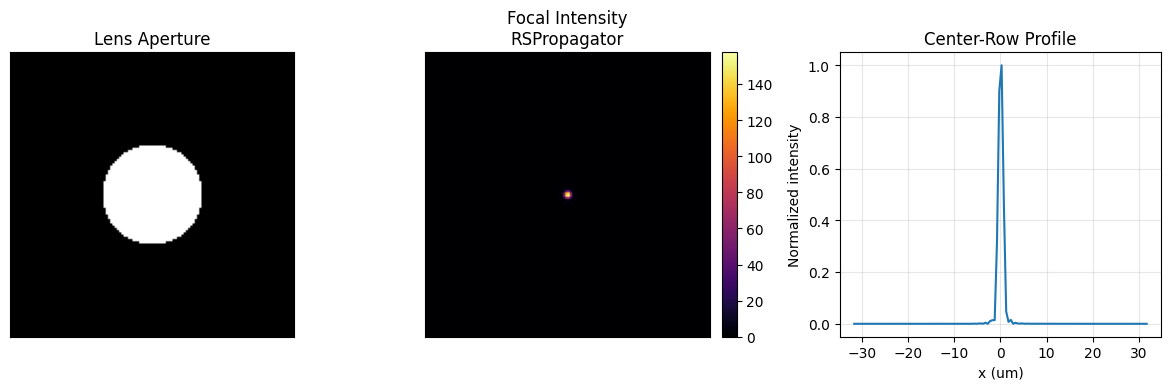

saved: artifacts/basic_propagation_overview.png


In [6]:
if PLOT:
    ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
    fig, axes = plt.subplots(1, 3, figsize=(12.0, 3.8))

    axes[0].imshow(aperture_mask, cmap="gray")
    axes[0].set_title("Lens Aperture")
    axes[0].set_xticks([])
    axes[0].set_yticks([])

    focus_im = axes[1].imshow(intensity, cmap="inferno")
    axes[1].set_title(f"Focal Intensity\n{propagator.__class__.__name__}")
    axes[1].set_xticks([])
    axes[1].set_yticks([])
    plt.colorbar(focus_im, ax=axes[1], fraction=0.046, pad=0.04)

    axes[2].plot(x_um, center_row / np.maximum(np.max(center_row), 1e-12))
    axes[2].set_title("Center-Row Profile")
    axes[2].set_xlabel("x (um)")
    axes[2].set_ylabel("Normalized intensity")
    axes[2].grid(alpha=0.3)

    fig.tight_layout()
    fig.savefig(PLOT_PATH, dpi=150)
    plt.show()
    print(f"saved: {PLOT_PATH}")
